In [52]:
import numpy as np
import matplotlib.pyplot as plt
import math
from numba import njit

1. Linia kwantylowa : pok. że dla B(t), L_aalpha(t) zachowują się potęgowo

X(t) =d= t^H X(1) w szereg, dla tych pr. H = 1/alpha, 
wykresik log X(t), log t, plot q_a(t), a - rząd linii, moze tez Xt, t

2. dobrac wyestymowac, wykladnik EA-TA-MSD(tau) ~ tau^Beta, dla r.Browna, Beta =1
TA-MSD(tau) ~ tau^Beta', dla kazdej trajkeotii + histogram Beta'

In [77]:
@njit
def get_random_a_stable(alpha, beta, gamma, delta):
    theta = np.random.uniform()*math.pi - math.pi/2
    theta_0 = np.arctan(beta*np.tan(math.pi*alpha/2))/alpha
    W = np.random.exponential()

    if alpha == 1:
        Z = 2/math.pi * ( (math.pi/2 + beta*theta)*np.tan(theta) - beta*np.log((math.pi/2 * W*np.cos(theta)) / (math.pi/2 + beta*theta)) )
        return gamma*Z + (delta + beta * 2/math.pi * gamma * np.log(gamma))
    else:
        Z = np.sin(alpha*(theta_0 + theta)) / ((np.cos(alpha*theta_0)*np.cos(theta))**(1/alpha)) * ( np.cos(alpha*theta_0 + (alpha - 1)*theta) / W )**((1 - alpha)/alpha)
        return gamma*Z + delta

In [76]:
@njit
def gen_process(alpha, beta, gamma, delta, dt, n):
    X = np.zeros(n)
    for i in range(1, n):
        X[i] = X[i-1] + get_random_a_stable(alpha, beta, gamma, delta)*dt**(1/alpha)
    return X

In [100]:
def gen_self_similar_process(alpha, beta, gamma, delta, dt, n, a=1, H=0.5): 
    X = a**(H)*gen_process(alpha, beta, gamma, delta, dt, n)
    Y = gen_process(alpha, beta, gamma, delta, dt*a, n)
    return np.array([X, Y])

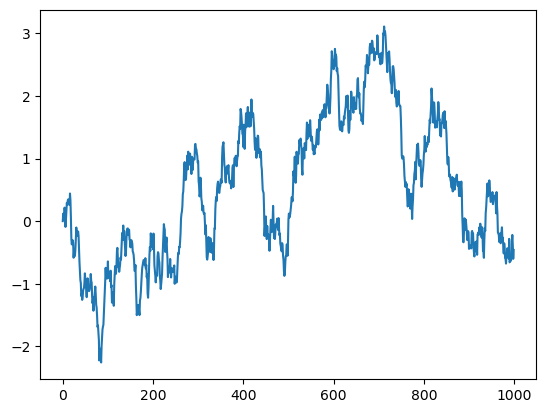

In [23]:
alpha = 2.0
beta = 0.5
gamma = 1
delta = 0
dt = 0.01
n = 1000

gen_process(alpha=alpha, beta=beta, gamma=gamma, delta=delta, dt=dt, n=n)
plt.plot(gen_process(alpha=alpha, beta=beta, gamma=gamma, delta=delta, dt=dt, n=n))
plt.show()

# LAB 9??

Samopodobne $(X(t)) $\
$(\forall c > 0) (X(ct) =^{fdd} c^H X(t))$\
tzn.\
$(\forall n \in \mathbb{N}) (\forall t_1<t_2<\ldots<t_n)$ mamy\
$[X(ct_1,\ldots,ct_n)]=c^H[X(t_1),\ldots,X(t_n)]$

*Transformata Lampertiego*

$(X(t))_{t\geq 0}$ $H$-samopodobny\
$Y(t)=e^{-tH}X(e^t), t\in \mathbb{R}$ jest stacjonarny

Problem 1. (Transformata Lampertiego ruchu Browna).\
Niech $(B_t)t\geq 0$ oznacza standardowy ruch Browna.
1. Zweryfikuj, że ruch Browna jest procesem samopodobnym z wykładnikiem $H = 1/2$\
(linie kwantylowe, badanie rozkładów w różnych punktach, ...)
2. Zastosuj transformatę Lampertiego do ruchu Browna\
$Y (t) = e−{t/2}B(e^t)$.\
Tutaj uważaj na dobranie chwil $t$: raczej chcemy by proces $Y$ był mierzony w równoodstępnych momentach.
3. Pokaż, że funkcja kowariancji procesu $(Y_t)$ dana jest wzorem\
$Cov(Y (s), Y (t)) = e^{−|t−s|/2}$.
4. Zidentyfikuj otrzymany proces.

In [ ]:
# sprawdzenie quantile lines dla prcocesu gen_process
def quantile_lines_for_process(process, dt):
    # Generowanie danych
    t = np.arange(0, 10, dt)

    # Obliczanie kwantyli
    quantiles = np.percentile(process, [5, 25, 50, 75, 95], axis=0)

    # Rysowanie wykresu
    plt.figure(figsize=(10, 6))
    plt.plot(t, quantiles[0], label='5th Percentile', color='blue')
    plt.plot(t, quantiles[1], label='25th Percentile', color='green')
    plt.plot(t, quantiles[2], label='50th Percentile (Median)', color='orange')
    plt.plot(t, quantiles[3], label='75th Percentile', color='red')
    plt.plot(t, quantiles[4], label='95th Percentile', color='purple')
    plt.title('Quantile Lines Over Time for gen_process')
    plt.xlabel('Time (t)')
    plt.ylabel('Value')
    plt.legend()
    plt.grid()
    plt.show()

In [118]:
# sprawdzenie quantile lines dla prcocesu gen_process
def quantile_lines_for_two_processes(process1, process2, dt):
    # Generowanie danych
    t = np.arange(0, 10, dt)

    # Obliczanie kwantyli
    quantiles1 = np.percentile(process1, [5, 95], axis=0)
    quantiles2 = np.percentile(process2, [5, 95], axis=0)

    # Rysowanie wykresu
    plt.figure(figsize=(10, 6))
    plt.plot(t, quantiles1[0], label='5th Percentile - Process 1', color='blue')
    plt.plot(t, quantiles1[1], label='25th Percentile - Process 1', color='green')
    plt.plot(t, quantiles2[0], label='5th Percentile - Process 2', color='lightblue')
    plt.plot(t, quantiles2[1], label='25th Percentile - Process 2', color='lightgreen')
    plt.title('Quantile Lines Over Time for gen_process')
    plt.xlabel('Time (t)')
    plt.ylabel('Value')
    plt.legend()
    plt.grid()
    plt.show()

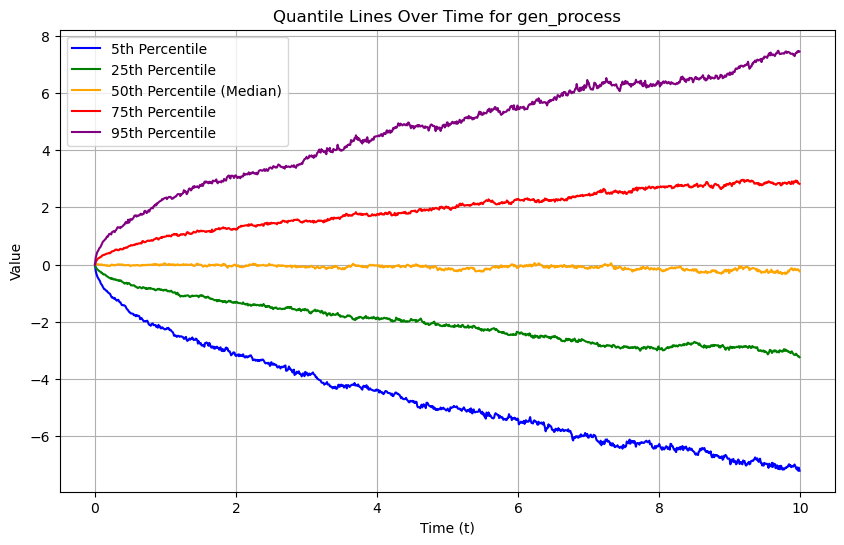

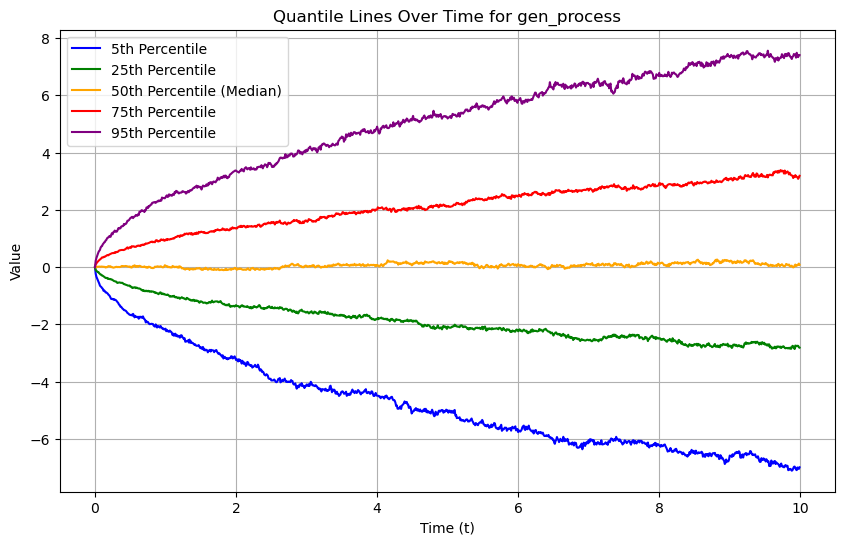

In [ ]:
dt = 0.01
n = 1000
a = 1
H = 0.5
data = np.array([gen_self_similar_process(alpha, beta, gamma, delta, dt, n, a, H) for _ in range(n)])
X = np.array([x[0] for x in data])
Y = np.array([x[1] for x in data])



quantile_lines_for_process(process=X, dt=dt)    
quantile_lines_for_process(process=Y, dt=dt)  


In [115]:

def quantile_lines_difference(process1, process2):
    quantiles1 = np.percentile(process1, [5, 25, 50, 75, 95], axis=0)
    quantiles2 = np.percentile(process2, [5, 25, 50, 75, 95], axis=0)
    return quantiles1 - quantiles2

In [107]:
def print_avg_deviation(avgDiviation, dt):
    t = np.arange(0, 10, dt)
    plt.figure(figsize=(10, 6))
    plt.plot(t, avgDiviation[0], label='5th Percentile Difference', color='blue')
    plt.plot(t, avgDiviation[1], label='25th Percentile Difference', color='green')
    plt.plot(t, avgDiviation[2], label='50th Percentile Difference (Median)', color='orange')
    plt.plot(t, avgDiviation[3], label='75th Percentile Difference', color='red')
    plt.plot(t, avgDiviation[4], label='95th Percentile Difference', color='purple')
    plt.title('Average Deviation of Quantile Lines Between gen_process and gen_self_similar_process')
    plt.xlabel('Time (t)')
    plt.ylabel('Average Deviation')
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
data = np.array([gen_self_similar_process(alpha, beta, gamma, delta, dt, n, a, H) for _ in range(n)])
X = np.array([x[0] for x in data])

type(X)

array([[ 0.00000000e+00, -1.15477019e-02, -2.14923853e-02, ...,
         4.94501389e+00,  4.95191483e+00,  5.11298841e+00],
       [ 0.00000000e+00, -5.21675488e-02, -3.50300705e-01, ...,
         1.43878863e+00,  1.47008186e+00,  1.35388690e+00],
       [ 0.00000000e+00,  6.75795434e-04, -1.13253226e-01, ...,
        -6.50928863e+00, -6.62464639e+00, -6.42431452e+00],
       ...,
       [ 0.00000000e+00, -2.81052467e-01, -4.25045478e-01, ...,
        -1.76408580e+00, -1.58124661e+00, -1.46737278e+00],
       [ 0.00000000e+00, -2.18281506e-01, -8.70926614e-02, ...,
        -1.94029286e+00, -1.89513823e+00, -1.94969844e+00],
       [ 0.00000000e+00, -3.70145084e-02, -2.55656617e-01, ...,
         2.27038934e+00,  2.29896586e+00,  2.20301066e+00]],
      shape=(1000, 1000))

In [116]:
def simulate_and_compare_processes(alpha, beta, gamma, delta, dt, n, a, H, numberOfSimulations):
    avgDiviation = np.zeros((5, int(10/dt)))
    for i in range(numberOfSimulations):
        data = np.array([gen_self_similar_process(alpha, beta, gamma, delta, dt, n, a, H) for _ in range(n)])
        X = np.array([x[0] for x in data])
        Y = np.array([x[1] for x in data])
        diff = quantile_lines_difference(process1=X, process2=Y)
        avgDiviation += diff

    avgDiviation /= numberOfSimulations
    print_avg_deviation(avgDiviation, dt)
    quantile_lines_for_two_processes(process1=X, process2=Y, dt=dt)
    #median plot
    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(0, 10, dt), avgDiviation[2], label='50th Percentile Difference (Median)', color='orange')
    plt.title('Average Deviation of 50th Percentile (Median) Between gen_process and gen_self_similar_process')
    plt.xlabel('Time (t)')
    plt.ylabel('Average Deviation of Median')
    plt.legend()
    plt.grid()
    plt.show()

    #mean plot
    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(0, 10, dt), np.mean(avgDiviation, axis=0), label='Mean Deviation of Quantiles', color='black')
    plt.title('Mean Deviation of Quantiles Between gen_process and gen_self_similar_process')
    plt.xlabel('Time (t)')
    plt.ylabel('Mean Deviation')
    plt.legend()
    plt.grid()
    plt.show()
    return avgDiviation


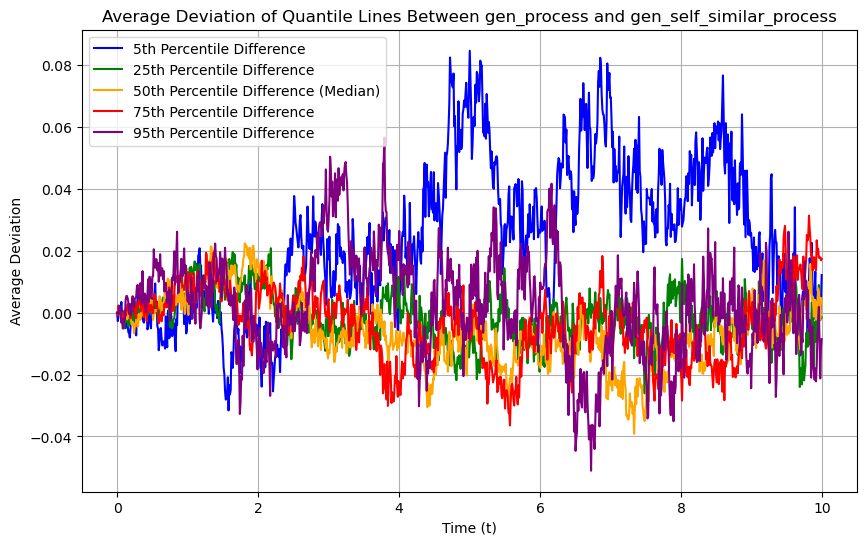

IndexError: index 2 is out of bounds for axis 0 with size 2

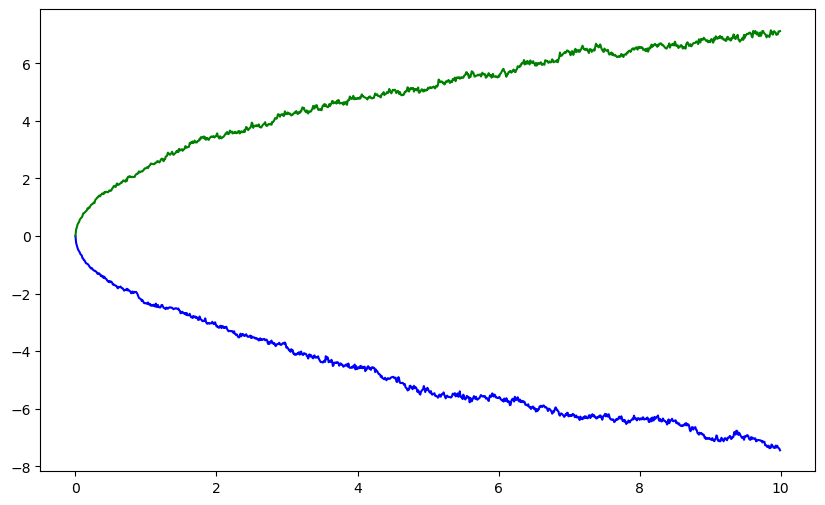

In [117]:
numberOfSimulations = 100
alpha = 2.0
beta = 0.5
gamma = 1
delta = 0
dt = 0.01
n = 1000
a = 1.0
H = 0.5
simulate_and_compare_processes(alpha, beta, gamma, delta, dt, n, a, H, numberOfSimulations)

Problem 2. (Symulacja procesu Ornsteina–Uhlenbecka przy użyciu transformaty Lampertiego). Korzystając z zasymulowanych trajektorii ruchu Browna, wygeneruj trajektorie procesu Ornsteina–Uhlenbecka przy użyciu transformaty Lampertiego.
1. Zasymuluj trajektorie ruchu Browna na przedziale $[0, T ]$.
2. Zastosuj transformatę Lampertiego.
3. Porównaj otrzymane trajektorie z trajektoriami generowanymi bezpośrednio z równania stochastycznego\
$dX_t = −\lambda X_t dt + \sigma dB_t$.
4. Porównaj funkcje kowariancji, rozkłady brzegowe oraz pozostałe zaimplementowane
wcześniej statystyki.


Problem 3. (Transformata Lampertiego ułamkowego ruchu Browna). Niech $(B_H (t))t\geq 0$ ozna-
cza ułamkowy ruch Browna z parametrem Hursta $H \in (0, 1)$.
1. Wysymuluj trajektorie ułamkowego ruchu Browna dla różnych wartości $H$. Skorzystaj z
paczki Pythonowej fbm lub somebm w R (najlepsza metoda: Davies-Harte/cyrkulant/circulant).
Zapoznaj się jak wygenerować trajektorie o danej długości z wybranym $H \in (0, 1)$.
2. Zastosuj transformatę Lampertiego
$Y_H (t) = e^{−Ht}B_H (e^t)$.
3. Zweryfikuj numerycznie, że otrzymany proces jest stacjonarny.
4. Porównaj funkcje kowariancji dla różnych wartości $H$.




Problem 4 (Badanie samopodobieństwa). Niech $(X_t)t\geq 0$ będzie jednym z następujących
procesów:
• ruch Browna,
• ułamkowy ruch Browna,
• α-stabilny ruch Lévy’ego.
Dla każdego procesu:
1. Wysymuluj trajektorie.
2. Zweryfikuj numerycznie zależność samopodobieństwa
X(at) d
≈ aH X(t).
3. Oszacuj parametr samopodobieństwa H przy użyciu:
• skalowania MSD,
• skalowania kwantyli,
• skalowania wariancji (jeśli ma to sens).
Problem 5 (Stacjonarność po transformacie Lampertiego). Rozważ następujące procesy:
• ruch Browna,
• ułamkowy ruch Browna,
• α-stabilny ruch Lévy’ego.
Zastosuj transformatę Lampertiego do każdego z procesów i zbadaj numerycznie, czy
otrzymany proces jest stacjonarny. W szczególności:
1. porównaj empiryczne rozkłady w różnych chwilach czasu,
2. porównaj strukturę kowariancji/kodyferencji,
3. porównaj kwantyle jako funkcje czasu.